# Project Health Data Science

## Data description

 ### Title: Maternal Health Risk of Pregnant Women

Data has been collected from different hospitals, community clinics, maternal health cares from the rural areas of Bangladesh through the IoT based risk monitoring system. 

Additional Information\
Age, Systolic Blood Pressure as SystolicBP, Diastolic BP as DiastolicBP, Blood Sugar as BS, Body Temperature as BodyTemp, HeartRate and RiskLevel. All these are the responsible and significant risk factors for maternal mortality, that is one of the main concern of SDG of UN.\
https://www.archive.ics.uci.edu/dataset/863/maternal+health+risk

## Objective

<span style="color:Blue">**To predict pregnancy-related complications risk level**</span>

## Variables Table

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import scikit_posthocs as sp
from sklearn import metrics

In [2]:
df_1 = pd.read_csv('Maternal_Health_Risk_Data_Set.csv')

In [3]:
pd.DataFrame({'Variable Name': df_1.columns,
             'Type' : ['integer','integer','integer','float','float','integer','category'],
             'Description' : ['Any ages in years when a women during pregnant.',
                             'Upper value of Blood Pressure in mmHg, another significant attribute during pregnancy.',
                             'Lower value of Blood Pressure in mmHg, another significant attribute during pregnancy.',
                             'Blood glucose levels is in terms of a molar concentration(mmol/L)',
                             'Body temperature(F)',
                             'A normal resting heart rate(bpm)',
                             'Predicted Risk Intensity Level during pregnancy considering the previous attribute.'],
             'Feature/Outcome' : ['Feature','Feature','Feature','Feature','Feature','Feature','Outcome']})

,Variable Name,Type,Description,Feature/Outcome
0,Age,integer,Any ages in years when a women during pregnant.,Feature
1,SystolicBP,integer,"Upper value of Blood Pressure in mmHg, another...",Feature
2,DiastolicBP,integer,"Lower value of Blood Pressure in mmHg, another...",Feature
3,BS,float,Blood glucose levels is in terms of a molar co...,Feature
4,BodyTemp,float,Body temperature(F),Feature
5,HeartRate,integer,A normal resting heart rate(bpm),Feature
6,RiskLevel,category,Predicted Risk Intensity Level during pregnanc...,Outcome


In [4]:
df_1.shape

(1014, 7)

## Data Preparation

In [5]:
df_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1014 entries, 0 to 1013
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          1014 non-null   int64  
 1   SystolicBP   1014 non-null   int64  
 2   DiastolicBP  1014 non-null   int64  
 3   BS           1014 non-null   float64
 4   BodyTemp     1014 non-null   float64
 5   HeartRate    1014 non-null   int64  
 6   RiskLevel    1014 non-null   object 
dtypes: float64(2), int64(4), object(1)
memory usage: 55.6+ KB


Change dtype of some columns to category:

In [6]:
df_1 = df_1.astype({'RiskLevel':'category'})

In [7]:
df_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1014 entries, 0 to 1013
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   Age          1014 non-null   int64   
 1   SystolicBP   1014 non-null   int64   
 2   DiastolicBP  1014 non-null   int64   
 3   BS           1014 non-null   float64 
 4   BodyTemp     1014 non-null   float64 
 5   HeartRate    1014 non-null   int64   
 6   RiskLevel    1014 non-null   category
dtypes: category(1), float64(2), int64(4)
memory usage: 48.8 KB


Check which column contains ANY missing value:

In [8]:
per_missing = df_1.isnull().sum() / len(df_1) * 100
per_missing 

Age            0.0
SystolicBP     0.0
DiastolicBP    0.0
BS             0.0
BodyTemp       0.0
HeartRate      0.0
RiskLevel      0.0
dtype: float64

*If have missing value:*

missing value >= 30% : remove columns

In [9]:
df_1 = df_1.loc[:, per_missing < 30]

missing value < 30% : 
1. numeric and not normal distribution : replace with median
2. numeric and normal distribution : replace with mean

check normal distribution:

In [10]:
print('Age:',stats.shapiro(df_1.Age))
print('SystolicBP:',stats.shapiro(df_1.SystolicBP))
print('DiastolicBP:',stats.shapiro(df_1.DiastolicBP))
print('BS:',stats.shapiro(df_1.BS))
print('BodyTemp:',stats.shapiro(df_1.BodyTemp))
print('HeartRate:',stats.shapiro(df_1.HeartRate))

Age: ShapiroResult(statistic=0.9160889983177185, pvalue=2.940027480229173e-23)
SystolicBP: ShapiroResult(statistic=0.9043952226638794, pvalue=1.1139652754045637e-24)
DiastolicBP: ShapiroResult(statistic=0.946744978427887, pvalue=1.1778083087462661e-18)
BS: ShapiroResult(statistic=0.673654317855835, pvalue=2.91405620850203e-40)
BodyTemp: ShapiroResult(statistic=0.5276755094528198, pvalue=1.401298464324817e-45)
HeartRate: ShapiroResult(statistic=0.9054552912712097, pvalue=1.4794961045751373e-24)


p-value < 0.05 \
<span style="color:Blue">**All features are not normal distributed.**</span>

In [11]:
df_1['Age'] = df_1['Age'].fillna(df_1['Age'].median())
df_1['SystolicBP'] = df_1['SystolicBP'].fillna(df_1['SystolicBP'].median())
df_1['DiastolicBP'] = df_1['DiastolicBP'].fillna(df_1['DiastolicBP'].median())
df_1['BS'] = df_1['BS'].fillna(df_1['BS'].median())
df_1['BodyTemp'] = df_1['BodyTemp'].fillna(df_1['BodyTemp'].median())
df_1['HeartRate'] = df_1['HeartRate'].fillna(df_1['HeartRate'].median())

Overall information:

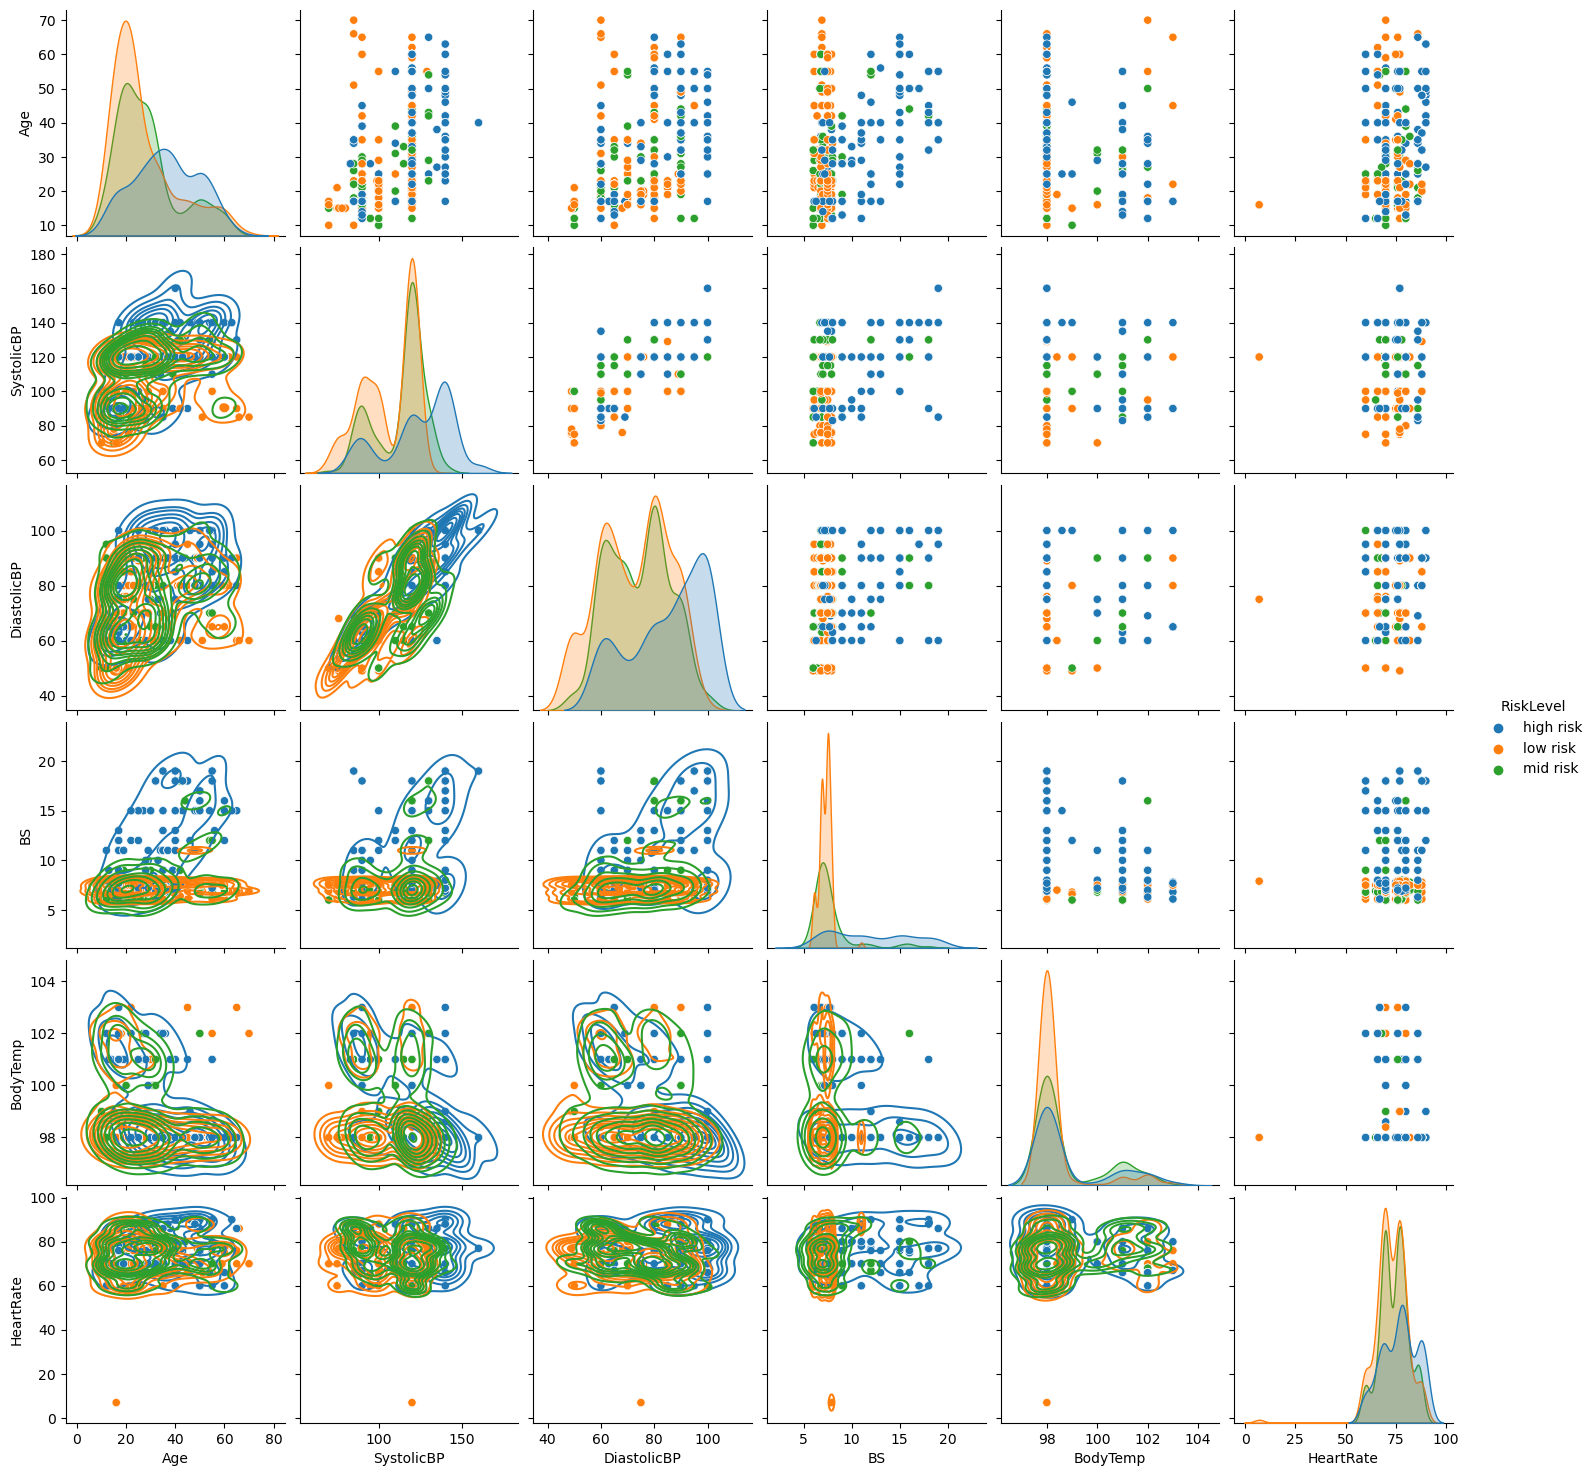

In [12]:
g = sns.pairplot(data=df_1,
             hue='RiskLevel')
g.map_lower(sns.kdeplot)

eliminate outlier:

In [13]:
q1, q3 = np.percentile(df_1.HeartRate, [25, 75])
print("q1:", q1)
print("q3:", q3)
IQR = q3 - q1
print("IQR: ", IQR)

q1: 70.0
q3: 80.0
IQR:  10.0


In [14]:
upper = df_1.HeartRate[df_1.HeartRate <= (q3 + 1.5*IQR)].max()
lower = df_1.HeartRate[df_1.HeartRate >= (q1 - 1.5*IQR)].min()
print("lower:",lower)
print("upper:",upper)

lower: 60
upper: 90


In [15]:
df = df_1[(df_1.HeartRate < upper) &
                     (df_1.HeartRate > lower)]
df.shape

(919, 7)

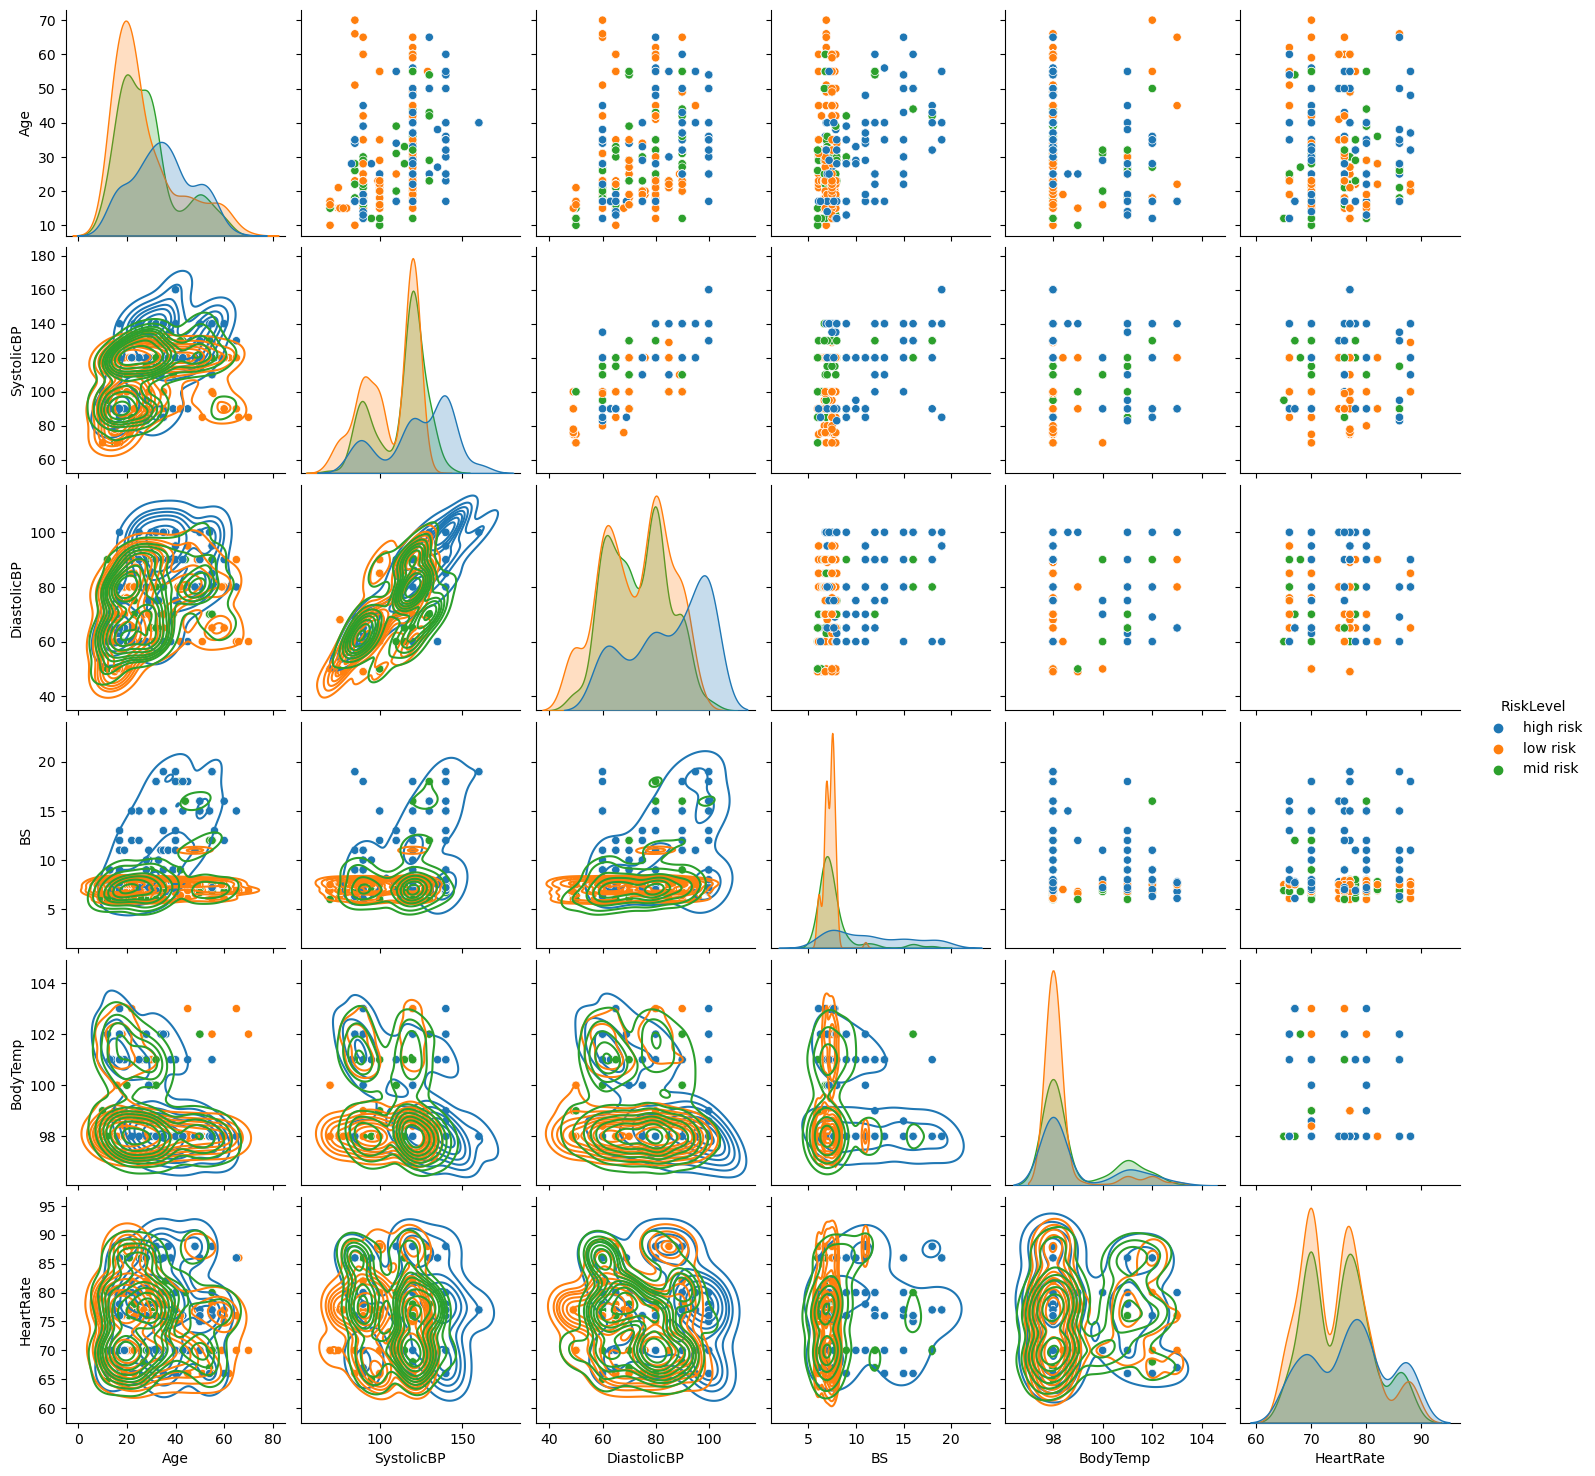

In [16]:
g = sns.pairplot(data=df,
             hue='RiskLevel')
g.map_lower(sns.kdeplot)

In [17]:
df.shape

(919, 7)

## Statistics Analysis

<span style="color:Blue">**From distribution test found that all features are not normal distributed at alpha is 0.05 indicate that comparison of more than two group means with non-normal distribution should use *Kruskal–Wallis test*.**</span>

Hypothesis : Kruskal–Wallis test\
H0: the actual difference between feature and each RiskLevel means is equal to 0.\
HA: the actual difference between feature and each RiskLevel means is not equal to 0.

In [18]:
f_score, p_value = stats.kruskal(df.query("RiskLevel == 'high risk'").Age, 
                                 df.query("RiskLevel == 'mid risk'").Age,
                                 df.query("RiskLevel == 'low risk'").Age)
print("Age & RiskLevel")
print("F-score:", f_score)
print("p-value:", p_value)

Age & RiskLevel
F-score: 68.14971897722039
p-value: 1.5902908218020743e-15


In [19]:
f_score, p_value = stats.kruskal(df.query("RiskLevel == 'high risk'").SystolicBP, 
                                 df.query("RiskLevel == 'mid risk'").SystolicBP,
                                 df.query("RiskLevel == 'low risk'").SystolicBP)
print("SystolicBP & RiskLevel")
print("F-score:", f_score)
print("p-value:", p_value)

SystolicBP & RiskLevel
F-score: 131.587704981731
p-value: 2.6674293169027714e-29


In [20]:
f_score, p_value = stats.kruskal(df.query("RiskLevel == 'high risk'").DiastolicBP, 
                                 df.query("RiskLevel == 'mid risk'").DiastolicBP,
                                 df.query("RiskLevel == 'low risk'").DiastolicBP)
print("DiastolicBP & RiskLevel")
print("F-score:", f_score)
print("p-value:", p_value)

DiastolicBP & RiskLevel
F-score: 110.65774328248075
p-value: 9.353547504713347e-25


In [21]:
f_score, p_value = stats.kruskal(df.query("RiskLevel == 'high risk'").BS, 
                                 df.query("RiskLevel == 'mid risk'").BS,
                                 df.query("RiskLevel == 'low risk'").BS)
print("BS & RiskLevel")
print("F-score:", f_score)
print("p-value:", p_value)

BS & RiskLevel
F-score: 244.91447324732172
p-value: 6.568978874834653e-54


In [22]:
f_score, p_value = stats.kruskal(df.query("RiskLevel == 'high risk'").BodyTemp, 
                                 df.query("RiskLevel == 'mid risk'").BodyTemp,
                                 df.query("RiskLevel == 'low risk'").BodyTemp)
print("BodyTemp & RiskLevel")
print("F-score:", f_score)
print("p-value:", p_value)

BodyTemp & RiskLevel
F-score: 36.743097090204586
p-value: 1.0503591978402296e-08


In [23]:
f_score, p_value = stats.kruskal(df.query("RiskLevel == 'high risk'").HeartRate, 
                                 df.query("RiskLevel == 'mid risk'").HeartRate,
                                 df.query("RiskLevel == 'low risk'").HeartRate)
print("HeartRate & RiskLevel")
print("F-score:", f_score)
print("p-value:", p_value)

HeartRate & RiskLevel
F-score: 26.880955814639528
p-value: 1.4550389218012113e-06


p-value < 0.05\
reject H0 : The actual difference between all features and each RiskLevel means is not equal to 0.\
<span style="color:Blue">**It's means all features effect to outcome.**</span>

## Model Prediction with Cross-Validation Techniques

In [24]:
X = df.drop('RiskLevel',axis=1)
y = df['RiskLevel']

### All of features are numeric. Indicate that features are not suspose to get dummies.

In [25]:
#df = pd.get_dummies(df, columns=[''],drop_first=True)

### Train / Test split

In [26]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test= train_test_split(X,
                                                    y,
                                                    test_size=0.3,
                                                    random_state=0)
#reset index
X_train = X_train.reset_index(drop=True) 
X_test = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

### <span style="color:Blue">Way 1: </span>

### imbalance problem

Check balance of RiskLevel data:

In [27]:
print(f'alzheimer = mid  risk : {df.RiskLevel[df.RiskLevel == "mid risk"].count()}')
print(f'alzheimer = low  risk : {df.RiskLevel[df.RiskLevel == "low risk"].count()}')
print(f'alzheimer = high risk : {df.RiskLevel[df.RiskLevel == "high risk"].count()}')

alzheimer = mid  risk : 315
alzheimer = low  risk : 371
alzheimer = high risk : 233


In [28]:
y.value_counts(normalize=True) * 100

low risk     40.369967
mid risk     34.276387
high risk    25.353645
Name: RiskLevel, dtype: float64

<Axes: xlabel='RiskLevel', ylabel='count'>

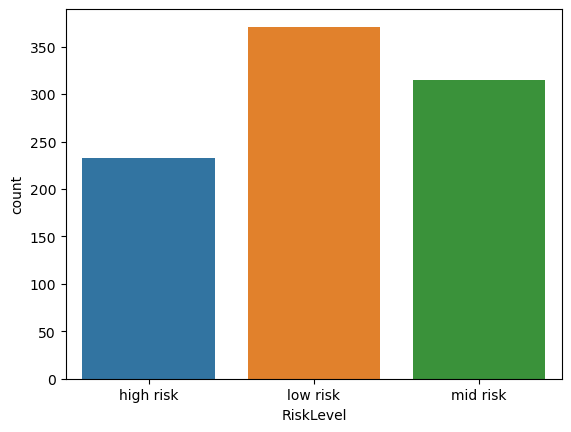

In [29]:
sns.countplot(df ,x=y)

It seem like 'high risk' may too low.

### Fix imbalance problem

SMOTE:

In [30]:
from imblearn.over_sampling import SMOTE
sm =SMOTE(sampling_strategy = 'minority', random_state = 42)
oversampled_X, oversampled_y = sm.fit_resample(X_train, y_train)
oversampled = pd.concat([pd.DataFrame(oversampled_y),pd.DataFrame(oversampled_X)], axis = 1)
oversampled.head()

,RiskLevel,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate
0,mid risk,12,95,60,6.9,98.0,65
1,low risk,60,90,65,7.0,98.0,77
2,mid risk,21,90,60,6.9,98.0,86
3,low risk,30,120,80,7.7,98.0,70
4,mid risk,28,90,60,7.5,98.0,82


In [31]:
print(f'alzheimer = mid  risk : {oversampled.RiskLevel[oversampled.RiskLevel == "mid risk"].count()}')
print(f'alzheimer = low  risk : {oversampled.RiskLevel[oversampled.RiskLevel == "low risk"].count()}')
print(f'alzheimer = high risk : {oversampled.RiskLevel[oversampled.RiskLevel == "high risk"].count()}')

alzheimer = mid  risk : 225
alzheimer = low  risk : 256
alzheimer = high risk : 256


<Axes: xlabel='RiskLevel', ylabel='count'>

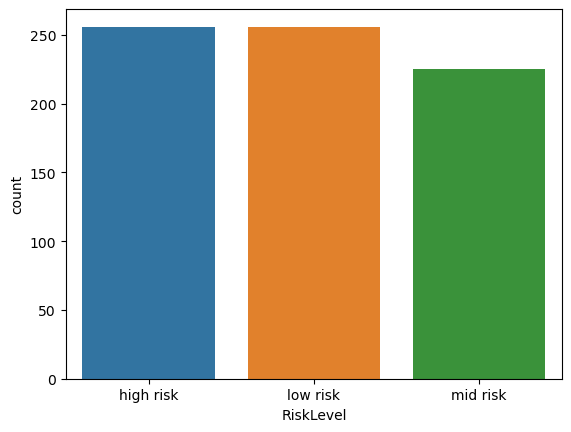

In [32]:
sns.countplot(oversampled ,x=oversampled_y)

### Train test split

In [33]:
X_trainSM, X_testSM, y_trainSM, y_testSM = train_test_split(oversampled_X,
                                                    oversampled_y,
                                                    test_size=0.3,
                                                    random_state=0)
#reset index
X_trainSM = X_trainSM.reset_index(drop=True) 
X_testSM = X_testSM.reset_index(drop=True)
y_trainSM = y_trainSM.reset_index(drop=True)
y_testSM = y_testSM.reset_index(drop=True)

In [34]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(criterion= 'log_loss',max_depth = 60, max_leaf_nodes=8)
rf.fit(X_trainSM,y_trainSM)
rf_predictions = rf.predict(X_test)

In [35]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, classification_report
from imblearn.metrics import specificity_score
class_sm = classification_report(y_test,rf_predictions,output_dict=True)
df_sm = pd.DataFrame(class_sm)
df_sm

,high risk,low risk,mid risk,accuracy,macro avg,weighted avg
precision,0.725275,0.708661,0.620690,0.695652,0.684875,0.684249
recall,0.929577,0.782609,0.400000,0.695652,0.704062,0.695652
f1-score,0.814815,0.743802,0.486486,0.695652,0.681701,0.678162
support,71.000000,115.000000,90.000000,0.695652,276.000000,276.000000


### <span style="color:Blue">Way 2: </span>

<span style="color:Blue">**Feature data scaling:** </span>

In [36]:
df.std(numeric_only=True)

Age            13.112083
SystolicBP     18.335292
DiastolicBP    13.638141
BS              3.090378
BodyTemp        1.387225
HeartRate       6.308115
dtype: float64

Performing feature data scaling:

In [37]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train) 

StandardScaler()

Scale training set:

In [38]:
X_train_sc = scaler.transform(X_train)
X_train_sc = pd.DataFrame(X_train_sc, columns=X_train.columns)

In [39]:
X_train_sc.std(numeric_only=True)

Age            1.000779
SystolicBP     1.000779
DiastolicBP    1.000779
BS             1.000779
BodyTemp       1.000779
HeartRate      1.000779
dtype: float64

Scale test set:

In [40]:
X_test_sc = scaler.transform(X_test)
X_test_sc = pd.DataFrame(X_test_sc, columns=X_test.columns)

In [41]:
X_test_sc.std(numeric_only=True)

Age            1.026142
SystolicBP     0.980757
DiastolicBP    1.029097
BS             1.081914
BodyTemp       1.020470
HeartRate      0.999263
dtype: float64

### K-fold cross-validation

**<span style="color:Blue">2.1  KNN model**</span>

**Evaluated KNN model on train set when n_neighbors = 1-30 by using stratified 5-fold cv**

In [42]:
from sklearn.model_selection import StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier as knn
skf = StratifiedKFold(n_splits=5,
                      shuffle=True,
                      random_state=0)
model_knn = knn(n_neighbors = 6)
y_train = y_train.reset_index(drop=True)
folds = skf.split(X=X_train_sc, y=y_train)

In [43]:
ks = range(1,31)

ovo vs ovr:

In [44]:
from sklearn.model_selection import cross_val_predict
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)

y_pred_proba_knn = cross_val_predict(estimator=model_knn,
                               X=X_train_sc,
                               y=y_train_encoded, 
                               cv=skf, 
                               method='predict_proba')  

In [45]:
auc_ovo = metrics.roc_auc_score(y_train, y_pred_proba_knn, multi_class='ovo', average='weighted')
auc_ovo

0.8324459899043355

In [46]:
auc_ovr = metrics.roc_auc_score(y_train, y_pred_proba_knn, multi_class='ovr', average='weighted')
auc_ovr

0.8226217390401496

Perform cv for each 'n_neighbors':

In [47]:
perf = {
    'n_neighbors': [],
    'acc': [],
    'precision': [],
    'recall': [],
    'f1': [],
    'auc': []
}

for k in ks:
    model_knn = knn(n_neighbors=k) 
    y_pred = cross_val_predict(estimator=model_knn,
                               X=X_train_sc,
                               y=y_train_encoded, 
                               cv=skf, 
                               method='predict_proba')  
    
    y_pred_labels = np.argmax(y_pred, axis=1)  
    
    acc = metrics.accuracy_score(y_train_encoded, y_pred_labels)
    precision = metrics.precision_score(y_train_encoded, y_pred_labels, average='weighted')
    recall = metrics.recall_score(y_train_encoded, y_pred_labels, average='weighted')
    f1 = metrics.f1_score(y_train_encoded, y_pred_labels, average='weighted')
    
    
    auc = metrics.roc_auc_score(y_train_encoded, y_pred, multi_class='ovo', average='weighted')
    
    perf['n_neighbors'].append(k)
    perf['acc'].append(acc)
    perf['precision'].append(precision)
    perf['recall'].append(recall)
    perf['f1'].append(f1)
    perf['auc'].append(auc)

perf = pd.DataFrame(perf)
perf.sort_values(by='acc', ascending=False).head()


,n_neighbors,acc,precision,recall,f1,auc
0,1,0.791602,0.796083,0.791602,0.792543,0.840662
1,2,0.729393,0.727699,0.729393,0.722975,0.849152
8,9,0.706065,0.707488,0.706065,0.703862,0.836316
12,13,0.699844,0.706717,0.699844,0.697942,0.831907
7,8,0.698289,0.698529,0.698289,0.692402,0.837364


Text(0.5, 1.0, '5-fold cv performance scores at different n_neighbors')

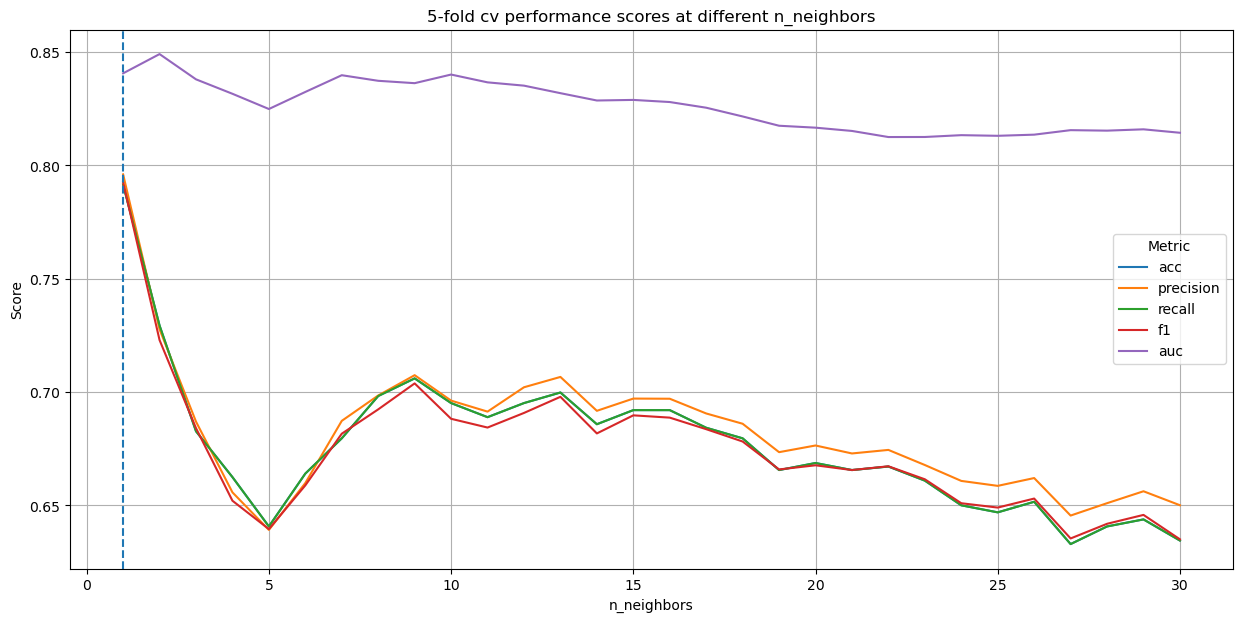

In [48]:
df_forPlot = pd.melt(perf,
                     value_vars = ['acc', 'precision', 'recall', 'f1', 'auc'],
                     id_vars = ['n_neighbors'],
                     var_name = 'Metric',
                     value_name = 'Score')
fig, ax = plt.subplots(figsize=(15, 7))
sns.lineplot(data = df_forPlot,
             x = 'n_neighbors',
             y = 'Score',
             hue = 'Metric',
             ax=ax)
plt.grid()
plt.axvline(x=1, ls="--")
plt.title('5-fold cv performance scores at different n_neighbors')

**Use KNN model with tuned 'n_neighbors' to predict test set**

In [49]:
model_knn = knn(n_neighbors=1)
model_knn.fit(X=X_train_sc, y=y_train)
y_pred_test_knn = model_knn.predict(X_test_sc)

In [50]:
class_knn = classification_report(y_test,y_pred_test_knn,output_dict=True)
df_knn = pd.DataFrame(class_knn)
df_knn

,high risk,low risk,mid risk,accuracy,macro avg,weighted avg
precision,0.835616,0.824074,0.684211,0.778986,0.781300,0.781436
recall,0.859155,0.773913,0.722222,0.778986,0.785097,0.778986
f1-score,0.847222,0.798206,0.702703,0.778986,0.782710,0.779673
support,71.000000,115.000000,90.000000,0.778986,276.000000,276.000000


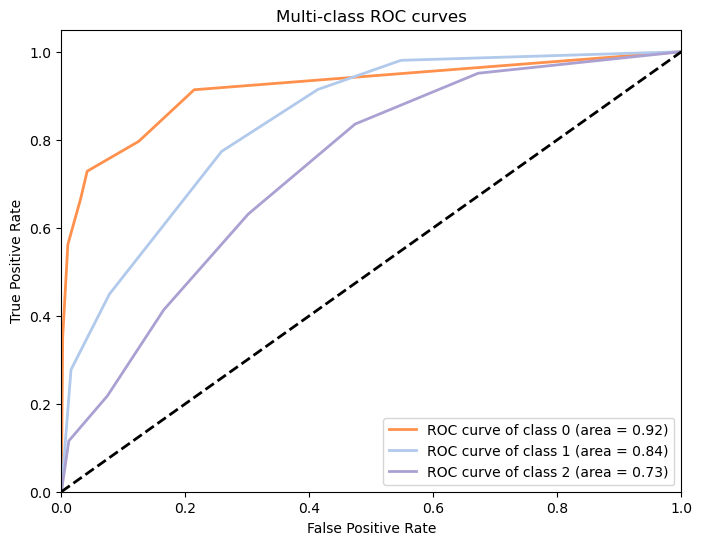

In [51]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, RocCurveDisplay,roc_auc_score
import matplotlib.pyplot as plt

# Binarize
y_train_binarized = label_binarize(y_train_encoded, classes=np.unique(y_train_encoded))

# Compute ROC curve and ROC area for each class
n_classes = y_train_binarized.shape[1]
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_train_binarized[:, i], y_pred_proba_knn[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot 
plt.figure(figsize=(8, 6))

colors = ['#FF914D', '#b1c9eb', '#aba0d2']
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label='ROC curve of class {0} (area = {1:0.2f})'.format(i, roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC curves')
plt.legend(loc="lower right")
plt.show()


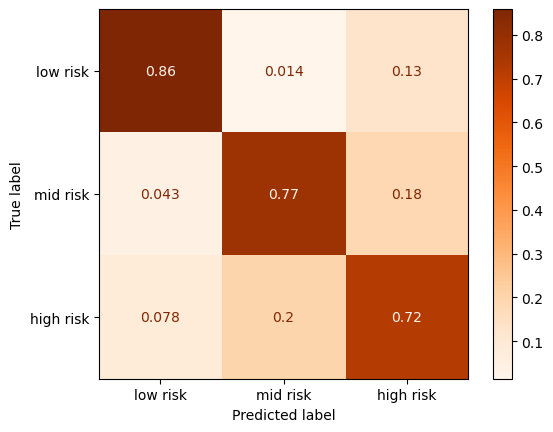

In [52]:
from sklearn.metrics import ConfusionMatrixDisplay,confusion_matrix
from matplotlib.colors import LinearSegmentedColormap

cm = confusion_matrix(y_test, y_pred_test_knn)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

disp = ConfusionMatrixDisplay(confusion_matrix=cm_normalized, display_labels=y_test.unique())

disp.plot(cmap=plt.get_cmap('Oranges'))
plt.show()

**<span style="color:Blue">2.2 SVM**</span>

**Tune 'C' (regularization parameter) in SVM model using 5-fold cv**

In [53]:
cs = [c for c in range(1,101) if c%10==0 or c==1]
cs

[1, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]

Configure cv:

In [54]:
skf = StratifiedKFold(n_splits=5,
                      shuffle=True,
                      random_state=0)

ovo vs ovr:

In [55]:
from sklearn import svm

model_svm = svm.SVC(kernel='rbf', C=1, probability=True)
y_pred_proba_svm = cross_val_predict(estimator=model_svm, 
                           X=X_train_sc, y=y_train, 
                           cv=skf, method='predict_proba')

In [56]:
auc_ovo = metrics.roc_auc_score(y_train, y_pred_proba_svm, multi_class='ovo', average='weighted')
auc_ovo

0.8360571452657297

In [57]:
auc_ovr = metrics.roc_auc_score(y_train, y_pred_proba_svm, multi_class='ovr', average='weighted')
auc_ovr

0.8222007522610381

Perform cv for each 'C':

In [58]:
perf = {}
perf['C'] = []
perf['acc'] = []
perf['precision'] = []
perf['recall'] = []
perf['f1'] = []
perf['auc'] = []

for c in cs:
    model_svm = svm.SVC(kernel='rbf', C=c, probability=True)
    y_pred = cross_val_predict(estimator=model_svm, 
                               X=X_train_sc, y=y_train, 
                               cv=skf, method='predict_proba')
    

    y_pred_labels = np.argmax(y_pred, axis=1)
    
    acc = accuracy_score(y_train_encoded, y_pred_labels)
    precision = precision_score(y_train_encoded, y_pred_labels, average='weighted')
    recall = recall_score(y_train_encoded, y_pred_labels, average='weighted')
    f1 = f1_score(y_train_encoded, y_pred_labels, average='weighted')
    auc = roc_auc_score(y_train_encoded, y_pred, multi_class='ovo', average='weighted')
    
    perf['C'].append(c)
    perf['acc'].append(acc)
    perf['precision'].append(precision)
    perf['recall'].append(recall)
    perf['f1'].append(f1)
    perf['auc'].append(auc)

perf_df = pd.DataFrame(perf)
perf_df.sort_values(by='acc', ascending=False).head()

,C,acc,precision,recall,f1,auc
9,90,0.737170,0.739372,0.737170,0.737710,0.860075
8,80,0.729393,0.731410,0.729393,0.729405,0.857936
10,100,0.729393,0.731441,0.729393,0.729617,0.860606
7,70,0.723173,0.724515,0.723173,0.722969,0.854905
4,40,0.720062,0.721869,0.720062,0.720172,0.853465


Plot performance scores for each 'C':

Text(0.5, 1.0, '5-fold cv performance scores at different C')

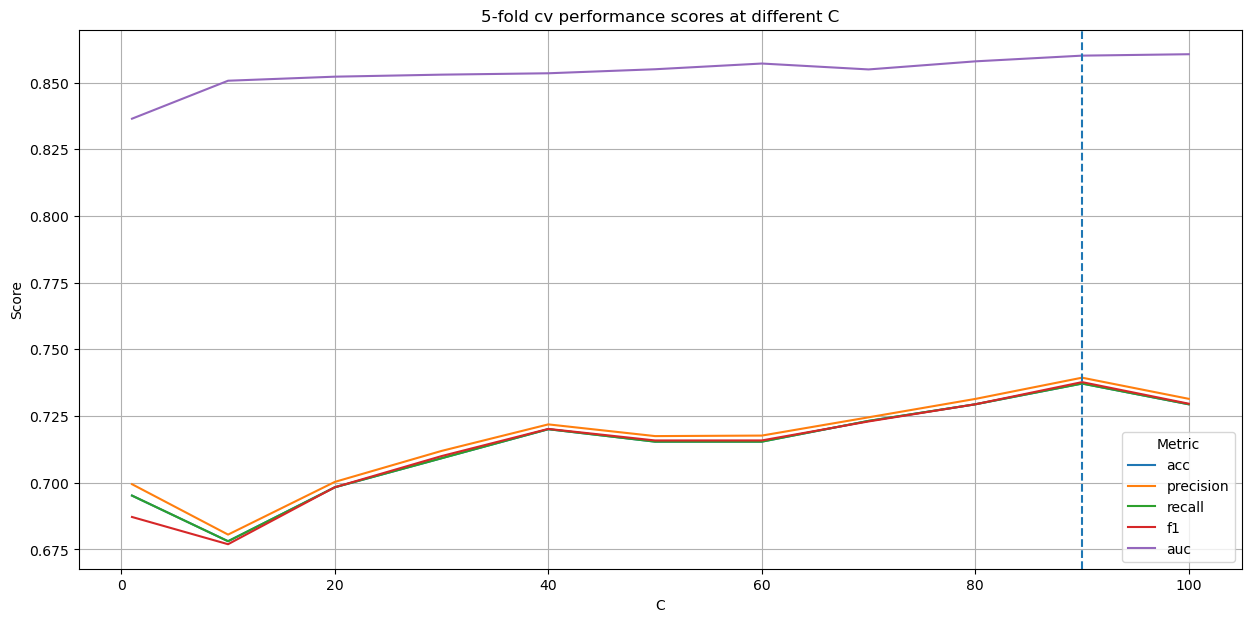

In [71]:
df_forPlot = pd.melt(perf_df,
                     value_vars = ['acc', 'precision', 'recall', 'f1', 'auc'],
                     id_vars = ['C'],
                     var_name = 'Metric',
                     value_name = 'Score')

fig, ax = plt.subplots(figsize=(15, 7))
sns.lineplot(data = df_forPlot,
             x = 'C',
             y = 'Score',
             hue = 'Metric',
             ax=ax)
plt.grid()
plt.axvline(x=90, ls="--")
plt.title('5-fold cv performance scores at different C')

**Use SVM model with tuned 'C' to predict test set**

In [72]:
model_svm = svm.SVC(kernel='rbf', C=90)
model_svm.fit(X=X_train_sc, y=y_train)
y_pred_test_svm = model_svm.predict(X_test_sc)

In [73]:
class_svm = classification_report(y_test,y_pred_test_svm,output_dict=True)
df_svm = pd.DataFrame(class_svm)
df_svm

,high risk,low risk,mid risk,accuracy,macro avg,weighted avg
precision,0.726190,0.767677,0.591398,0.695652,0.695088,0.699522
recall,0.859155,0.660870,0.611111,0.695652,0.710379,0.695652
f1-score,0.787097,0.710280,0.601093,0.695652,0.699490,0.694437
support,71.000000,115.000000,90.000000,0.695652,276.000000,276.000000


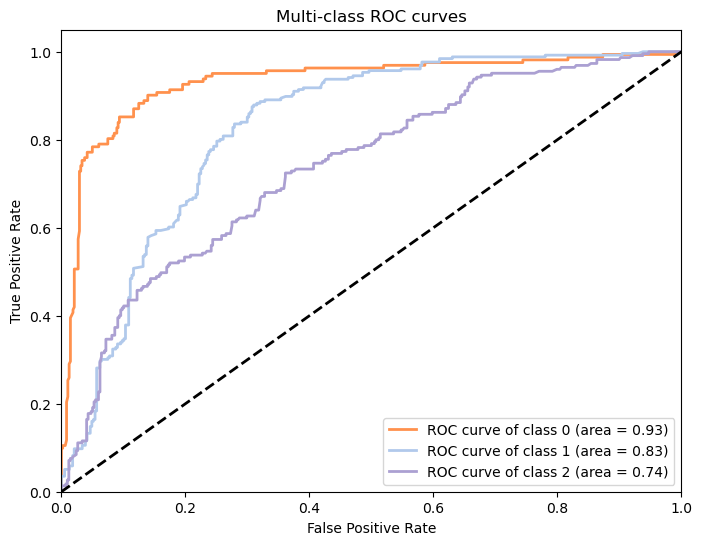

In [74]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, RocCurveDisplay,roc_auc_score
import matplotlib.pyplot as plt

# Binarize
y_train_binarized = label_binarize(y_train_encoded, classes=np.unique(y_train_encoded))

# Compute ROC curve and ROC area for each class
n_classes = y_train_binarized.shape[1]
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_train_binarized[:, i], y_pred_proba_svm[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot 
plt.figure(figsize=(8, 6))

colors = ['#FF914D', '#b1c9eb', '#aba0d2']
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label='ROC curve of class {0} (area = {1:0.2f})'.format(i, roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC curves')
plt.legend(loc="lower right")
plt.show()


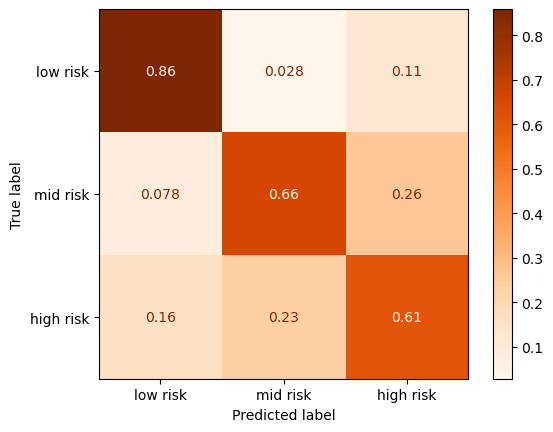

In [75]:
cm = confusion_matrix(y_test, y_pred_test_svm)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

disp = ConfusionMatrixDisplay(confusion_matrix=cm_normalized, display_labels=y_test.unique())

disp.plot(cmap=plt.get_cmap('Oranges'))
plt.show()

**<span style="color:Blue">2.3 ANN </span>**

In [64]:
param_dist = {
    'neurons': [64, 128, 256, 512],
    'batch_size': [8, 16, 32],
    'epochs': [50, 100, 200]
}

In [65]:
layers = {'config1':(128, 64, 32),
          'config2':(128, 64, 32, 16),
          'config3':(128, 64, 32, 16, 8)}
for k,v in layers.items():
    print(v)

(128, 64, 32)
(128, 64, 32, 16)
(128, 64, 32, 16, 8)


In [66]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_val_predict
perf = {}
perf['hidden_conf'] = []
perf['acc'] = []

for k,v in layers.items():
    model_ann = MLPClassifier(hidden_layer_sizes=v,
                              activation='relu',
                              solver='adam',
                              random_state=0, 
                              learning_rate='adaptive'
                              )
    
    # predict class
    y_pred = cross_val_predict(estimator=model_ann,
                               X=X_train_sc,
                               y=y_train,
                               cv=skf) 
    acc = metrics.accuracy_score(y_train, y_pred)
    
    perf['hidden_conf'].append(k)
    perf['acc'].append(acc)

perf = pd.DataFrame(perf)
perf.sort_values(by='acc', ascending=False)

/Users/kitsanathepmatraksa/anaconda3/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/kitsanathepmatraksa/anaconda3/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/kitsanathepmatraksa/anaconda3/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/kitsanathepmatraksa/anaconda3/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged ye

,hidden_conf,acc
1,config2,0.760498
0,config1,0.748056
2,config3,0.748056


In [67]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

# Create a pipeline with a scaler and the MLP classifier
pipe = Pipeline([
    ('scaler', StandardScaler()),  # It's important to scale inputs for ANN
    ('mlp', MLPClassifier(max_iter=1000, random_state=1))  # MLP with more iterations for convergence
])

# Define a grid of parameters to search over
param_grid = {
    'mlp__hidden_layer_sizes': [(50,), (100,), (50, 50), (100, 100), (50, 100, 50)]
}

# Set up GridSearchCV to find the best parameters
grid_search = GridSearchCV(pipe, param_grid, n_jobs=-1, cv=5)

# Run the grid search
grid_search.fit(X_train_sc, y_train)

# Best parameter and score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print("Best parameters found: ", best_params)
print("Best cross-validation score: {:.2f}".format(best_score))

/Users/kitsanathepmatraksa/anaconda3/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/kitsanathepmatraksa/anaconda3/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/kitsanathepmatraksa/anaconda3/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/kitsanathepmatraksa/anaconda3/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converge

Best parameters found:  {'mlp__hidden_layer_sizes': (50, 100, 50)}
Best cross-validation score: 0.77


In [68]:
ann = MLPClassifier(hidden_layer_sizes=(50, 100, 50),
                    activation='relu',
                    solver='adam',
                    random_state=0, 
                    learning_rate='adaptive')
ann.fit(X=X_train_sc, y=y_train)
y_pred_test_ann = ann.predict(X_test_sc)

In [69]:
class_ann = classification_report(y_test,y_pred_test_ann,output_dict=True)
df_ann = pd.DataFrame(class_ann)
df_ann

,high risk,low risk,mid risk,accuracy,macro avg,weighted avg
precision,0.704545,0.777778,0.675000,0.724638,0.719108,0.725425
recall,0.873239,0.730435,0.600000,0.724638,0.734558,0.724638
f1-score,0.779874,0.753363,0.635294,0.724638,0.722844,0.721682
support,71.000000,115.000000,90.000000,0.724638,276.000000,276.000000


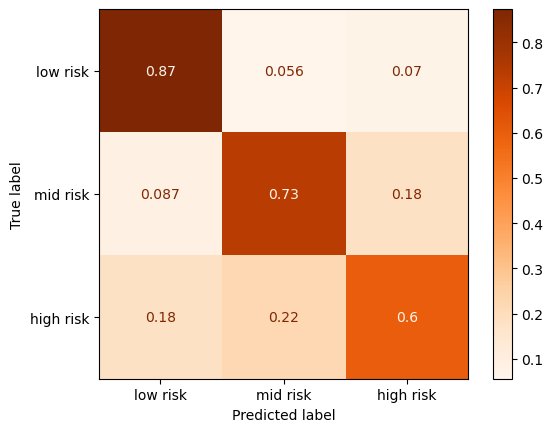

In [70]:
cm = confusion_matrix(y_test, y_pred_test_ann)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

disp = ConfusionMatrixDisplay(confusion_matrix=cm_normalized, display_labels=y_test.unique())

disp.plot(cmap=plt.get_cmap('Oranges'))
plt.show()